In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
from drawarrow import ax_arrow
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [2]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   activity_id        446 non-null    int64              
 1   name               446 non-null    object             
 2   type               446 non-null    category           
 3   start_datetime     446 non-null    datetime64[ns, UTC]
 4   end_datetime       446 non-null    datetime64[ns, UTC]
 5   date               446 non-null    datetime64[ns]     
 6   month              446 non-null    object             
 7   weekday            446 non-null    object             
 8   start_hour         446 non-null    int32              
 9   distance_km        446 non-null    float64            
 10  distance_miles     446 non-null    float64            
 11  moving_time_mins   446 non-null    float64            
 12  elapsed_time_mins  446 non-null    float64        

# Distribution Plot

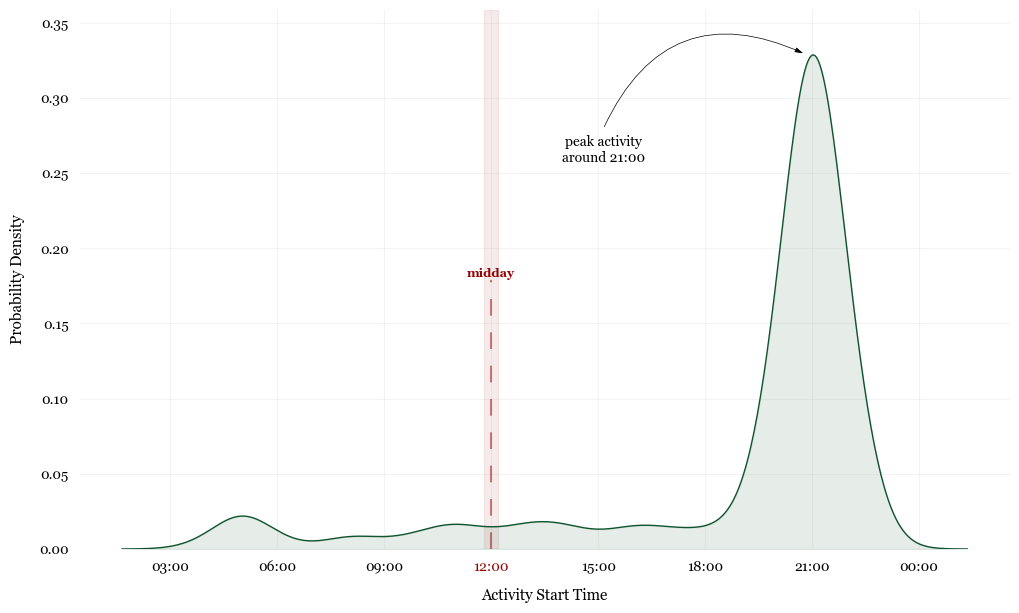

In [ ]:
# choose colours
midday_colour = "#950404FF"
line_colour = "#0F542FFF"

# create a figure for visualisation
fig, ax = plt.subplots(figsize=(12, 7))

# axes customisation
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)    # remove all plot borders
ax.grid(True, alpha=0.15)                                           # add a light background grid   
ax.tick_params(length=0, pad=8, labelsize=10)

# x-axis formatting
x_range = np.arange(0, 25, 3)
ax.set_xticks(x_range)

# hardcode the 24:00 label as 00:00
xtick_labels = [f"{int(x_range[i]):02d}:00" for i in range(len(x_range) - 1)] + [f"00:00"]
ax.set_xticklabels(xtick_labels)
ax.set_xlabel("Activity Start Time", labelpad=10)
ax.set_ylabel("Probability Density", labelpad=10)

# choose a colour palette
cmap = load_cmap("AsteroidCity1")
colours = cmap.colors

# plot a histogram (discrete bins)
# ax.hist(
#     x=df["start_hour"],
#     bins=np.arange(0, 23, 1),   # hourly bin edges from 0 to 24
#     density=True
# )

# plot a midday line (noon)
ax.axvline(
    x=12,
    ymax=0.5,
    linewidth=1.5,
    linestyle=(0, (8, 8)),      # dashed
    alpha=0.5,
    color=midday_colour,
)
ax.text(
    x=12, y=0.5,      
    s="midday",
    # x in data coords, y in axes coords
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    weight="bold",
    fontsize=9,
    color=midday_colour,
)

# shaded band around noon
ax.axvspan(11.8, 12.2, color=midday_colour, alpha=0.08)

# colour only the midday (12:00) tick label
for label, tick in zip(ax.get_xticklabels(), x_range):
    if tick == 12:
        label.set_color(midday_colour)
        # label.set_fontweight("bold")   

# plot KDE from seaborn
kde_params = {
    "ax": ax,
    "color": "tab:purple",
    "bw_adjust": 0.6,
    # "clip": (0, 24),
    "gridsize": 500
}
sns.kdeplot(
    data=df,
    x="start_hour",
    ax=ax,
    color=line_colour,
    bw_adjust=0.6,          # bandwidth: higher = smoother
    # clip=(0, 24),
    gridsize=500,           # no. of data points to construct line
    linewidth=1,
)

# get KDE line x and y values data
line = ax.lines[len(ax.lines) - 1]      # index is the last made line
x_kde, y_kde = line.get_xdata(), line.get_ydata()

# find the peak point
peak_idx = np.argmax(y_kde)
x_peak, y_peak = x_kde[peak_idx], y_kde[peak_idx]

# fill under KDE line plot
ax.fill_between(
    x=x_kde,
    y1=0, 
    y2=y_kde,
    alpha=0.1,
    color=line_colour
)

# arrow: point to the peak
x_tail, y_tail = x_peak * .72, y_peak * .85
ax_arrow(
    head_position=(x_peak * .99, y_peak * 1.001),
    tail_position=(x_tail, y_tail),
    fill_head=True,
    head_width=1.5,
    head_length=5,
    color="black",
    radius=-0.5,
    width=0.5
)

# annotation text: state peak activity 
ax.text(
    x=x_tail, y=y_tail * 0.95,
    s=f"peak activity\naround {x_peak:.0f}:00",
    ha="center",
    va="center",
    fontsize=10
)

# save figure as SVG
plt.savefig("../images/activity_start_time_kde.svg", bbox_inches="tight")

plt.show()